In [ ]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    train_test_split, cross_val_score, GroupKFold,
)
# 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")

Data inladen + enkele waarden bekijken 

In [2]:
data = pd.read_csv("Data/Diversity_data_with_biooracle_2010.csv")
data.head()
data.columns

Index(['marine_species_richness', 'PD', 'co1_genetic_diversity_mean',
       'long_deg', 'lat_deg', 'chl_max', 'chl_mean', 'chl_min', 'clt_max',
       'clt_mean', 'clt_min', 'currentdirection_max', 'currentdirection_mean',
       'currentdirection_min', 'currentvelocity_ltmax', 'currentvelocity_max',
       'currentvelocity_mean', 'currentvelocity_min', 'dfe_max', 'dfe_mean',
       'dfe_min', 'kdpar_max', 'kdpar_mean', 'kdpar_min', 'mlotst_max',
       'mlotst_mean', 'mlotst_min', 'no3_max', 'no3_mean', 'no3_min', 'o2_max',
       'o2_mean', 'o2_min', 'par_mean', 'par_min', 'phyc_max', 'phyc_mean',
       'phyc_min', 'ph_max', 'ph_mean', 'ph_min', 'po4_max', 'po4_mean',
       'po4_min', 'salinity_ltmax', 'salinity_ltmin', 'salinity_max',
       'salinity_mean', 'salinity_min', 'salinity_range', 'siconc_max',
       'siconc_mean', 'siconc_min', 'sithick_max', 'sithick_mean',
       'sithick_min', 'si_max', 'si_mean', 'si_min', 'tas_max', 'tas_mean',
       'tas_min', 'terrain_charact

In [4]:
data2 = pd.read_csv("Data/Diversity_data_with_env.csv")
data2.head()
data2.columns

Index(['grid_id', 'long', 'lat', 'marine_species_richness', 'PD',
       'co1_genetic_diversity_mean', 'long_deg', 'lat_deg', 'long_dd',
       'lat_dd', 'DepthMin', 'DepthMax', 'DepthMean', 'ClimZoneCode',
       'SSTAnMean', 'SBTAnMean', 'SalinityMean', 'SalinityBMean',
       'PrimProdMean', 'IceConAnn', 'OxyMean', 'OxyBMean', 'LandDist', 'Shelf',
       'Slope', 'Abyssal', 'TidalRange', 'Coral', 'Estuary', 'Seamount', 'MPA',
       'matched_CenterLong', 'matched_CenterLat'],
      dtype='object')

Data van 2 datasets samenvoegen 

In [5]:
data_samen = data.merge(data2, on = ["long_deg", "lat_deg"])
data_samen.tail()
data_samen.columns

print(f"Diversity_data_with_env:             {data_samen.shape}")
# de data samen heeft 2452 rijen en 106  kolommen 

Diversity_data_with_env:             (2452, 106)


Variabelen en biodiversiteitsmaat selecteren om model mee te bouwen 

In [ ]:
target = "PD_x" # Geselecteerde biodiversiteitsmaat om te voorspellen.

feature_cols = [ # Dit zijn de variabelen die we hier selecteren om de biodiversiteit te voorspellen.
    "clt_mean",        
    "currentdirection_mean",
    "currentvelocity_mean",
    "dfe_mean",
    "mlotst_mean",
    "o2_mean",
    "par_mean",
    "phyc_mean",
    "ph_mean",
    "po4_mean",
    "salinity_mean",
    "si_mean",
    "tas_mean",
    "terrain_characteristics_bea_mean",
    "terrain_characteristics_slope",
    "T_mean", 
    "LandDist",
]    # onderaan de code staat de optimalisatie van de variabelen om te
# weten welke we hier het best gebruiken in ons model 

In [8]:
df = data_samen[[target] + feature_cols].copy()
print(f"Shape before cleaning: {df.shape}")  
df.describe() 

Shape before cleaning: (2452, 18)


,PD_x,clt_mean,currentdirection_mean,currentvelocity_mean,dfe_mean,mlotst_mean,o2_mean,par_mean,phyc_mean,ph_mean,po4_mean,salinity_mean,si_mean,tas_mean,terrain_characteristics_bea_mean,terrain_characteristics_slope,T_mean,LandDist
count,2452.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2202.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2.217000e+03,2217.000000,2452.000000
mean,97.907775,0.447101,152.689401,0.096974,0.000404,48.266381,257.423756,52.920432,1.538574,8.043805,0.673196,34.520979,14.698095,14.624145,-3748.862966,1.179893e+00,16.382824,644.398042
std,115.578176,0.186835,80.485733,0.096603,0.000829,28.577804,53.447055,7.715883,0.745757,0.025790,0.700528,1.583589,26.476457,11.465120,1538.097895,1.406274e+00,10.565343,541.423334
min,4.177602,0.027449,8.444567,0.001367,0.000005,6.990705,197.984285,11.559936,0.554283,7.793579,0.000169,3.213432,0.656868,-16.241398,-7138.611328,2.484808e-17,-1.838033,0.000000
25%,34.835263,0.271776,74.841409,0.036148,0.000070,29.868310,208.600594,47.684359,1.213635,8.033113,0.090502,33.910668,1.594731,5.300397,-4841.555664,3.307500e-01,6.396754,204.000000
50%,47.090843,0.450085,138.466769,0.068392,0.000143,41.403713,235.609703,55.216059,1.444429,8.044218,0.381472,34.541424,2.670603,17.737980,-4115.527832,7.419182e-01,19.306662,525.500000
75%,96.951054,0.613930,233.689689,0.125637,0.000330,56.961308,305.790494,58.743515,1.622265,8.056951,1.198416,35.364977,13.881882,25.288107,-3187.027832,1.471722e+00,26.387225,987.250000
max,512.751559,0.785068,315.692114,1.121662,0.009292,199.046201,387.724233,65.981354,13.682373,8.141021,2.234311,38.747336,121.972284,28.490869,0.000000,1.466965e+01,30.261832,2632.000000


Alle ontbrekende waarden verwijderen 

In [9]:
df.replace(-9999.0, np.nan, inplace=True)
df.replace(-9999, np.nan, inplace=True)

missing = df.isna().sum() # Ontbrekende waarden tellen.
print("Missing values per column:\n")
print(missing[missing > 0])

df.dropna(inplace=True) # Ontbrekende waarden verwijderen.
print(f"\nShape after dropping rows with NaN: {df.shape}")

Missing values per column:

clt_mean                            235
currentdirection_mean               235
currentvelocity_mean                235
dfe_mean                            235
mlotst_mean                         235
o2_mean                             235
par_mean                            250
phyc_mean                           235
ph_mean                             235
po4_mean                            235
salinity_mean                       235
si_mean                             235
tas_mean                            235
terrain_characteristics_bea_mean    235
terrain_characteristics_slope       235
T_mean                              235
dtype: int64

Shape after dropping rows with NaN: (2202, 18)


Histogram van de biodiversiteitsmaat

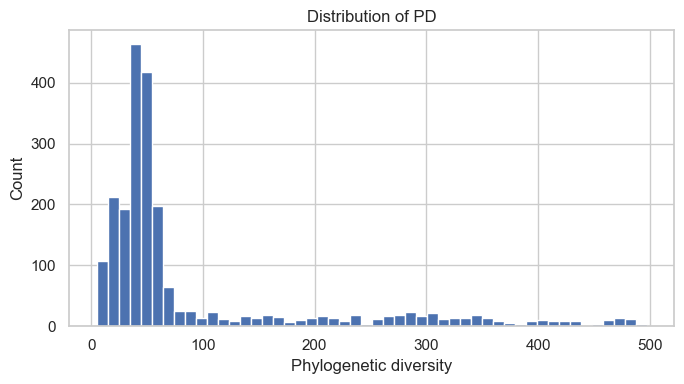

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df[target], bins=50, edgecolor="white")
ax.set_xlabel("Phylogenetic diversity")
ax.set_ylabel("Count")
ax.set_title("Distribution of PD")
plt.tight_layout()
plt.show()

Correlatie van de variabelen voor in het model 

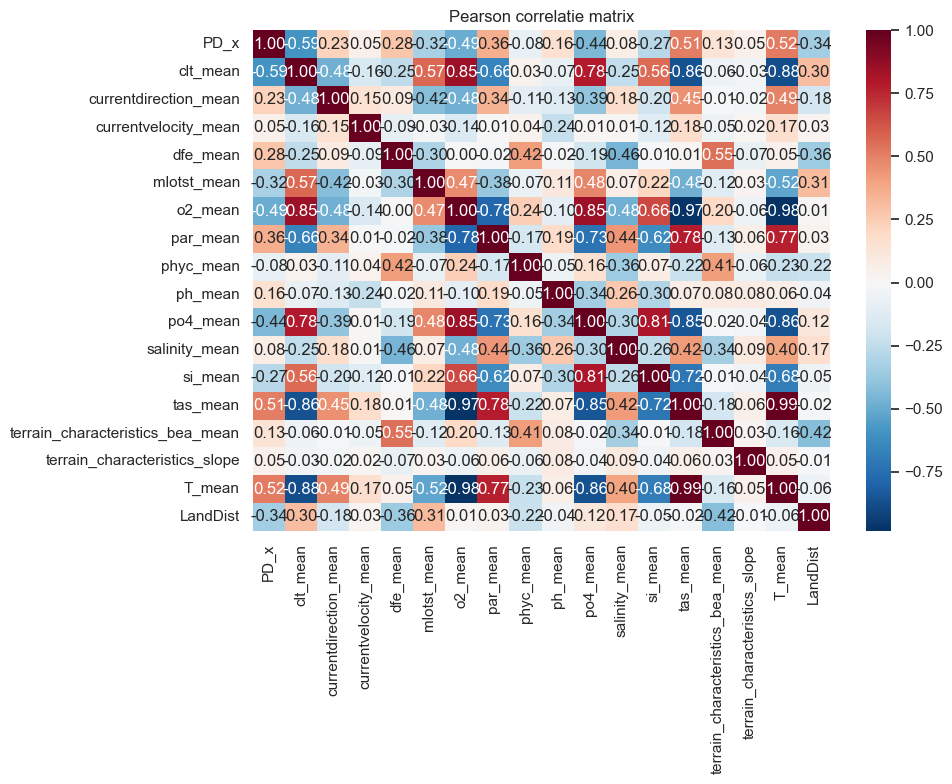

In [11]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Pearson correlatie matrix")
plt.tight_layout()
plt.show()

Willekeurig splitsen van de data in een trainig set en test set 

In [12]:
X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2026
)

X_train.columns
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Training samples: 1761
Test samples:     441


Het model zelf met hyperparameters

In [13]:
rf = RandomForestRegressor(
    n_estimators=800,
    max_depth=20,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",800
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Het volgende stukje code is om de hyperparameters te optimaliseren. Niet meer uitvoeren want dit duurt mega lang
Ik kwam uit voor mijn model 
- n_estimators = 800
- max_depth = 20
- leaf = 1

In [ ]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestRegressor

# rf = RandomForestRegressor(random_state=42)

# de hyperparameters optimaliseren 
# param_grid = {
   #  "n_estimators": [200, 500, 800],
   #  "max_depth": [10, 20, 30, None],
   #  "min_samples_leaf": [1, 5, 10],
   #  "max_features": ["sqrt", 0.3, 0.5]
# }

# grid = GridSearchCV(
   #  rf,
   #  param_grid,
   #  cv=5,
   #  scoring="r2",
   #  n_jobs=-1
# )

# grid.fit(X_train, y_train)

# print(grid.best_params_)

Model trainen en performantie 

In [14]:
y_pred = rf.predict(X_test)

r2_train = rf.score(X_train, y_train)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Train R² : {r2_train:.4f}")
print(f"Test  R² : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"\nTrain–test gap: {r2_train - r2:.4f}")

Train R² : 0.9578
Test  R² : 0.7156
RMSE     : 60.7318
MAE      : 34.1520

Train–test gap: 0.2422


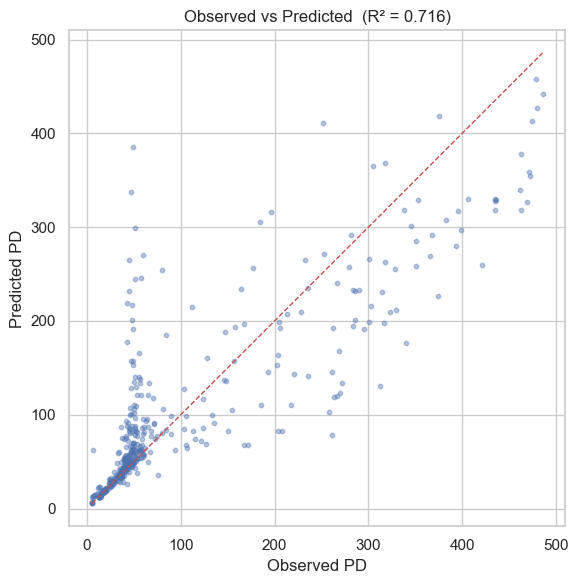

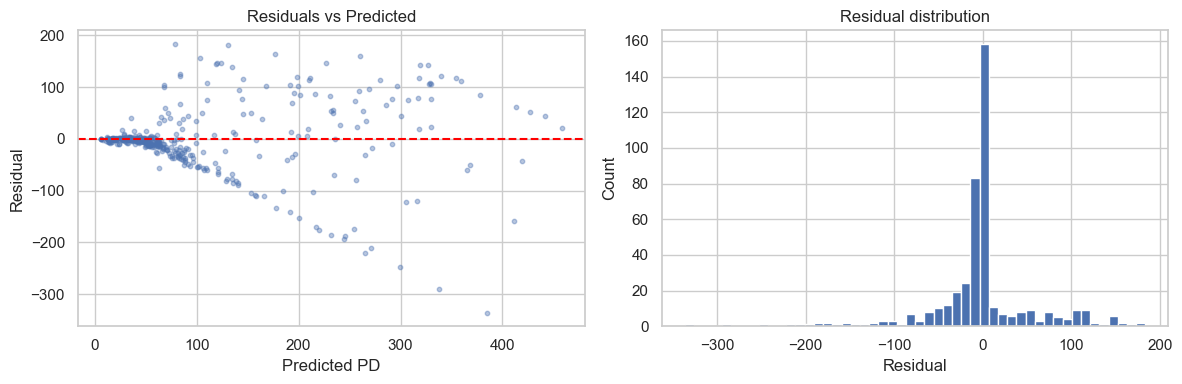

In [15]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, s=10, alpha=0.4)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("Observed PD")
ax.set_ylabel("Predicted PD")
ax.set_title(f"Observed vs Predicted  (R² = {r2:.3f})")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].scatter(y_pred, residuals, s=10, alpha=0.4)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted GD")
axes[0].set_xlabel("Predicted PD")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=50, edgecolor="white")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()

Feature importance

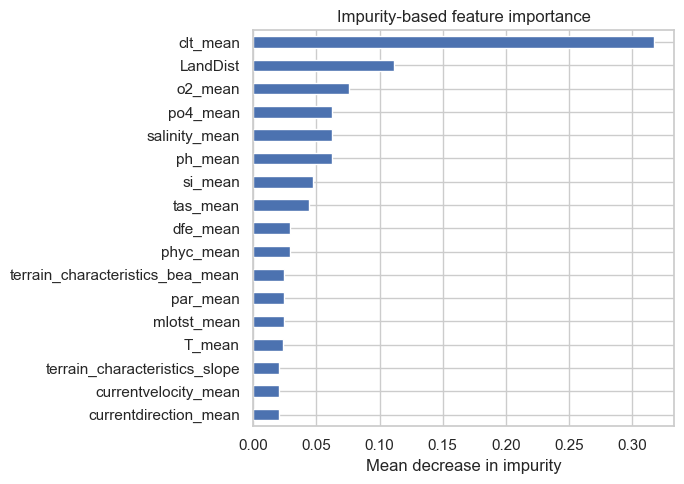

In [16]:
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()


fig, ax = plt.subplots(figsize=(7, 5))
imp.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Impurity-based feature importance")
plt.tight_layout()
plt.show()

De 10 minst belangrijkste feeatures

In [17]:
top_features = imp.head(10).index.tolist()
print(top_features)

['currentdirection_mean', 'currentvelocity_mean', 'terrain_characteristics_slope', 'T_mean', 'mlotst_mean', 'par_mean', 'terrain_characteristics_bea_mean', 'phyc_mean', 'dfe_mean', 'tas_mean']


Spatial crossvalidation (CV)

In [18]:
lat = data.loc[df.index, "lat_deg"]
lon = data.loc[df.index, "long_deg"]
lat_bin = pd.cut(lat, bins=np.arange(-90, 91, 10), labels=False)
lon_bin = pd.cut(lon, bins=np.arange(-180, 181, 10), labels=False)
spatial_blocks = lat_bin.astype(str) + "_" + lon_bin.astype(str)

print(f"\nSpatial blocks (10°×10° grid): {spatial_blocks.nunique()} unique blocks")

gkf = GroupKFold(n_splits=5)
spatial_cv = cross_val_score(
    rf, X, y, cv=gkf, groups=spatial_blocks, scoring="r2", n_jobs=-1,
)
print("Spatial  5-fold CV R² scores:", np.round(spatial_cv, 4))
print(f"Mean R²: {spatial_cv.mean():.4f}  ±  {spatial_cv.std():.4f}")


Spatial blocks (10°×10° grid): 422 unique blocks
Spatial  5-fold CV R² scores: [0.653  0.623  0.6468 0.5677 0.7446]
Mean R²: 0.6470  ±  0.0573


De volgende code is om je variabelen te reduceren om het beste model te maken 

In [19]:
target = "PD_x" # Geselecteerde biodiversiteitsmaat om te voorspellen.

feature_cols = [ # Dit zijn de variabelen die we hier selecteren om de biodiversiteit te voorspellen.
    "chl_mean",      # variabelen kiezen die invloed gaan hebben op de biodiversiteit  
    "clt_mean",        
    "currentdirection_mean",
    "currentvelocity_mean",
    "dfe_mean",
    "kdpar_mean",
    "mlotst_mean",
    "no3_mean",
    "o2_mean",
    "par_mean",
    "phyc_mean",
    "ph_mean",
    "po4_mean",
    "salinity_mean",
    "siconc_mean",
    "sithick_mean",
    "si_mean",
    "tas_mean",
    "terrain_characteristics_aspect",
    "terrain_characteristics_bea_mean",
    "terrain_characteristics_rug",
    "terrain_characteristics_slope",
    "terrain_characteristics_topo",
    "T_mean", 
    "DepthMean",
    "LandDist",
    "Shelf",
    "Slope",
    "Abyssal",
    "Seamount",
]

In [20]:
df = data_samen[[target] + feature_cols].copy()
print(f"Shape before cleaning: {df.shape}")  
df.describe()

Shape before cleaning: (2452, 31)


,PD_x,chl_mean,clt_mean,currentdirection_mean,currentvelocity_mean,dfe_mean,kdpar_mean,mlotst_mean,no3_mean,o2_mean,...,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean,DepthMean,LandDist,Shelf,Slope,Abyssal,Seamount
count,2452.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2215.000000,2217.000000,2217.000000,2217.000000,...,2217.000000,2.217000e+03,2217.000000,2217.000000,2452.000000,2452.000000,2452.000000,2452.000000,2452.000000,2452.000000
mean,97.907775,0.259398,0.447101,152.689401,0.096974,0.000404,0.068529,48.266381,7.874852,257.423756,...,94.427332,1.179893e+00,-2.727722,16.382824,3395.364192,644.398042,106.702485,907.614120,1149.016243,0.092577
std,115.578176,0.215264,0.186835,80.485733,0.096603,0.000829,0.023235,28.577804,10.287690,53.447055,...,106.862539,1.406274e+00,76.048905,10.565343,1807.135985,541.423334,418.417273,1081.733066,1189.317748,0.411971
min,4.177602,0.043151,0.027449,8.444567,0.001367,0.000005,0.001578,6.990705,0.000422,197.984285,...,0.000000,2.484808e-17,-658.309052,-1.838033,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.835263,0.105136,0.271776,74.841409,0.036148,0.000070,0.056053,29.868310,0.020503,208.600594,...,30.402771,3.307500e-01,-28.128448,6.396754,2556.000000,204.000000,0.000000,0.000000,0.000000,0.000000
50%,47.090843,0.244400,0.450085,138.466769,0.068392,0.000143,0.065386,41.403713,2.020931,235.609703,...,62.715210,7.419182e-01,-1.149323,19.306662,3944.000000,525.500000,0.000000,135.741786,842.324758,0.000000
75%,96.951054,0.346993,0.613930,233.689689,0.125637,0.000330,0.074361,56.961308,15.241677,305.790494,...,117.663208,1.471722e+00,19.500183,26.387225,4753.250000,987.250000,0.000000,1840.672129,2359.201000,0.000000
max,512.751559,3.750575,0.785068,315.692114,1.121662,0.009292,0.322310,199.046201,36.047286,387.724233,...,1098.482654,1.466965e+01,748.565994,30.261832,7660.000000,2632.000000,3088.682000,3089.624000,3089.624000,8.000000


In [21]:

df.replace(-9999.0, np.nan, inplace=True)
df.replace(-9999, np.nan, inplace=True)

missing = df.isna().sum() # Ontbrekende waarden tellen.
print("Missing values per column:\n")
print(missing[missing > 0])

df.dropna(inplace=True) # Ontbrekende waarden verwijderen.
print(f"\nShape after dropping rows with NaN: {df.shape}")

Missing values per column:

chl_mean                            235
clt_mean                            235
currentdirection_mean               235
currentvelocity_mean                235
dfe_mean                            235
kdpar_mean                          237
mlotst_mean                         235
no3_mean                            235
o2_mean                             235
par_mean                            250
phyc_mean                           235
ph_mean                             235
po4_mean                            235
salinity_mean                       235
siconc_mean                         235
sithick_mean                        235
si_mean                             235
tas_mean                            235
terrain_characteristics_aspect      235
terrain_characteristics_bea_mean    235
terrain_characteristics_rug         235
terrain_characteristics_slope       235
terrain_characteristics_topo        235
T_mean                              235
dtype: int64

In [22]:
X = df[feature_cols]
y = df[target]

In [ ]:
from sklearn.feature_selection import RFECV

# Random Forest
estimator = RandomForestRegressor(
    n_estimators=800,
    max_depth=20,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# RFECV met spatial CV + RMSE
selector = RFECV(
    estimator,
    step=1,
    cv=gkf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

selector.fit(X, y, groups=spatial_blocks)

print(f"Optimal number of features: {selector.n_features_}")

selected_features_RFECV = X.columns[selector.support_]
print("Selected features:", list(selected_features_RFECV))